In [2]:
!pip install yfinance pandas numpy matplotlib seaborn scipy --quiet

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import yfinance as yf
import warnings 
warnings.filterwarnings('ignore')
print('ok')

ok


In [11]:
# BIST100 verisini Yahoo Finance'tan çekiyoruz
ticker = "XU100.IS"
veri = yf.download(ticker, start="2020-01-01", end="2024-12-31", progress=False)

# Sadece kapanış fiyatlarını alalım — .squeeze() ile Series'e çeviriyoruz
kapanis = veri['Close'].squeeze().dropna()

ilk  = float(kapanis.iloc[0])
son  = float(kapanis.iloc[-1])

print(f" Veri aralığı : {kapanis.index[0].date()} → {kapanis.index[-1].date()}")
print(f" Gözlem sayısı: {len(kapanis)} işlem günü")
print(f" İlk fiyat   : {ilk:,.0f} puan")
print(f" Son fiyat   : {son:,.0f} puan")
print(f" Toplam getiri: %{((son/ilk)-1)*100:.1f}")


 Veri aralığı : 2020-01-02 → 2024-12-30
 Gözlem sayısı: 1247 işlem günü
 İlk fiyat   : 1,159 puan
 Son fiyat   : 9,890 puan
 Toplam getiri: %753.1


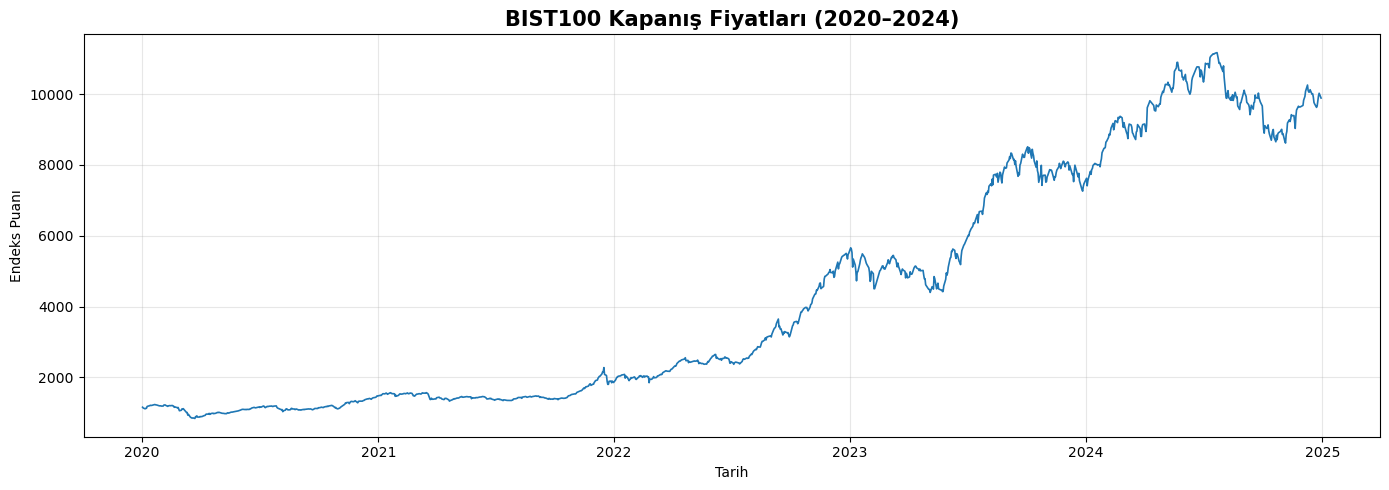

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(kapanis.index, kapanis.values, color='#1f77b4', linewidth=1.2)

plt.title('BIST100 Kapanış Fiyatları (2020–2024)', fontsize=15, fontweight='bold')
plt.xlabel('Tarih')
plt.ylabel('Endeks Puanı')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 📌 Grafik Yorumu

**BIST100 (2020–2024)** nominal bazda yaklaşık **%1.000'in üzerinde** artış göstermiştir.
Ancak bu yükselişin önemli bir kısmı **enflasyon etkisiyle** açıklanabilir.

Dikkat çeken dönemler:
- 🔴 **Mart 2020** — COVID-19 paniğiyle sert düşüş
- 🟡 **2021–2022** — Kur krizi ve faiz tartışmaları, yüksek volatilite
- 🟢 **2023–2024** — Ortodoks para politikasına dönüş, yabancı yatırımcı ilgisi

> Bu yüzden fiyat yolunu simüle ederken **log-getiri** bazında çalışmak daha doğrudur.
> Bir sonraki adımda bunu hesaplayacağız. 👇

In [13]:
# Günlük log-getiri hesabı
# Log-getiri = ln(S_t / S_{t-1})
log_getiri = np.log(kapanis / kapanis.shift(1)).dropna()

print(f" Ortalama günlük getiri : %{log_getiri.mean()*100:.4f}")
print(f" Günlük volatilite (σ)  : %{log_getiri.std()*100:.4f}")
print(f" Yıllık getiri (μ)      : %{log_getiri.mean()*252*100:.2f}")
print(f" Yıllık volatilite (σ)  : %{log_getiri.std()*np.sqrt(252)*100:.2f}")
print(f" Çarpıklık (Skewness)   : {log_getiri.skew():.4f}")
print(f" Basıklık (Kurtosis)    : {log_getiri.kurt():.4f}")

 Ortalama günlük getiri : %0.1720
 Günlük volatilite (σ)  : %1.8216
 Yıllık getiri (μ)      : %43.35
 Yıllık volatilite (σ)  : %28.92
 Çarpıklık (Skewness)   : -0.7196
 Basıklık (Kurtosis)    : 4.5288


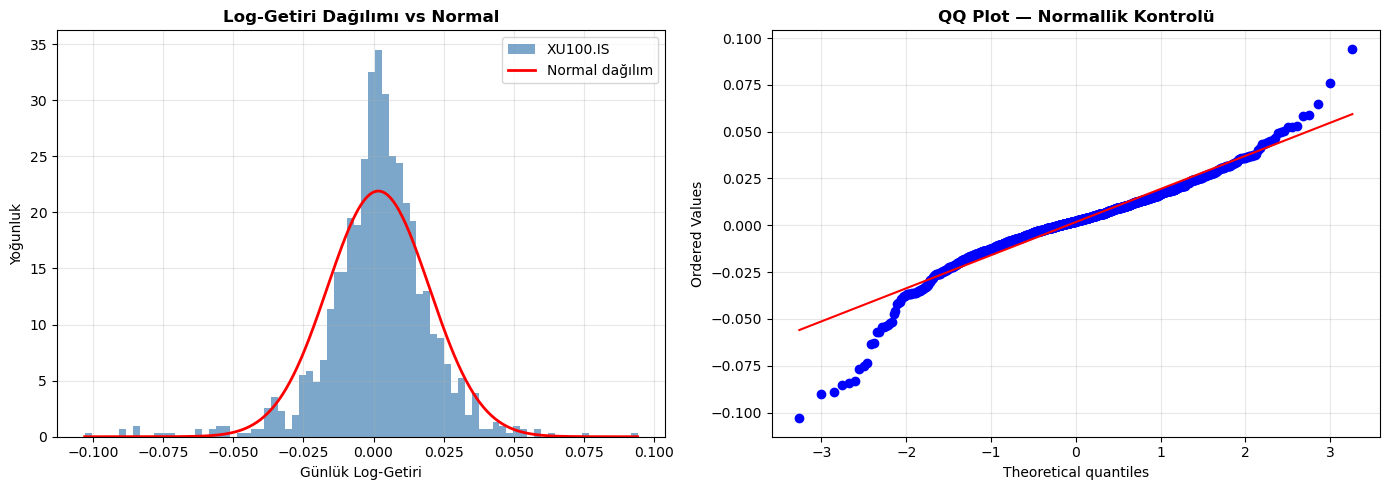

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol grafik — histogram + normal dağılım karşılaştırması
ax1 = axes[0]
log_getiri.plot(kind='hist', bins=80, density=True, 
                color='steelblue', alpha=0.7, ax=ax1)

# Teorik normal dağılım eğrisi
x = np.linspace(log_getiri.min(), log_getiri.max(), 300)
normal_egri = stats.norm.pdf(x, log_getiri.mean(), log_getiri.std())
ax1.plot(x, normal_egri, 'r-', linewidth=2, label='Normal dağılım')

ax1.set_title('Log-Getiri Dağılımı vs Normal', fontweight='bold')
ax1.set_xlabel('Günlük Log-Getiri')
ax1.set_ylabel('Yoğunluk')
ax1.legend()
ax1.grid(alpha=0.3)

# Sağ grafik — QQ Plot (normallik testi)
ax2 = axes[1]
stats.probplot(log_getiri, dist="norm", plot=ax2)
ax2.set_title('QQ Plot — Normallik Kontrolü', fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# GBM parametrelerini gerçek veriden tahmin et (MLE — Maximum Likelihood)
mu_gunluk    = log_getiri.mean()
sigma_gunluk = log_getiri.std()

# Yıllık bazda (252 işlem günü)
mu_yillik    = mu_gunluk * 252
sigma_yillik = sigma_gunluk * np.sqrt(252)

# GBM drift terimi — dikkat: mu - sigma²/2 !
drift = mu_gunluk - 0.5 * sigma_gunluk**2

print("=" * 40)
print("  GBM Parametre Kalibrasyonu")
print("=" * 40)
print(f"  μ  (yıllık getiri)    : %{mu_yillik*100:.2f}")
print(f"  σ  (yıllık volatilite): %{sigma_yillik*100:.2f}")
print(f"  Drift terimi (μ-σ²/2) : {drift:.6f}")
print("=" * 40)

  GBM Parametre Kalibrasyonu
  μ  (yıllık getiri)    : %43.35
  σ  (yıllık volatilite): %28.92
  Drift terimi (μ-σ²/2) : 0.001555


In [16]:
# Simülasyon parametreleri
np.random.seed(42)          # Tekrar üretilebilirlik için sabit tohum
N_SENARYO  = 10_000         # Senaryo sayısı
N_GUN      = 30             # Kaç gün ileriye bakıyoruz
S0         = float(kapanis.iloc[-1])  # Başlangıç fiyatı = son kapanış

# Simülasyon matrisi: her satır bir gün, her sütun bir senaryo
epsilon = np.random.standard_normal((N_GUN, N_SENARYO))

# GBM adım adım hesabı
# S_{t+1} = S_t * exp(drift*dt + sigma*sqrt(dt)*epsilon)
dt = 1  # günlük adım
gunluk_getiri = np.exp(drift * dt + sigma_gunluk * np.sqrt(dt) * epsilon)

# Fiyat yolları: her sütun bir senaryo
fiyat_yollari = np.zeros((N_GUN + 1, N_SENARYO))
fiyat_yollari[0] = S0
for t in range(1, N_GUN + 1):
    fiyat_yollari[t] = fiyat_yollari[t-1] * gunluk_getiri[t-1]

# Dönem sonu fiyatlar
son_fiyatlar = fiyat_yollari[-1]

print(f" {N_SENARYO:,} senaryo × {N_GUN} gün simüle edildi!")
print(f" Başlangıç fiyatı : {S0:,.0f} puan")
print(f" Ortalama sonuç   : {son_fiyatlar.mean():,.0f} puan")
print(f" Medyan sonuç     : {np.median(son_fiyatlar):,.0f} puan")

 10,000 senaryo × 30 gün simüle edildi!
 Başlangıç fiyatı : 9,890 puan
 Ortalama sonuç   : 10,414 puan
 Medyan sonuç     : 10,368 puan


<bound method _AxesBase.set_xlabel of <Axes: title={'center': 'BIST100 Monte Carlo Simülasyonu\n10,000 Senaryo × 30 Gün'}>>

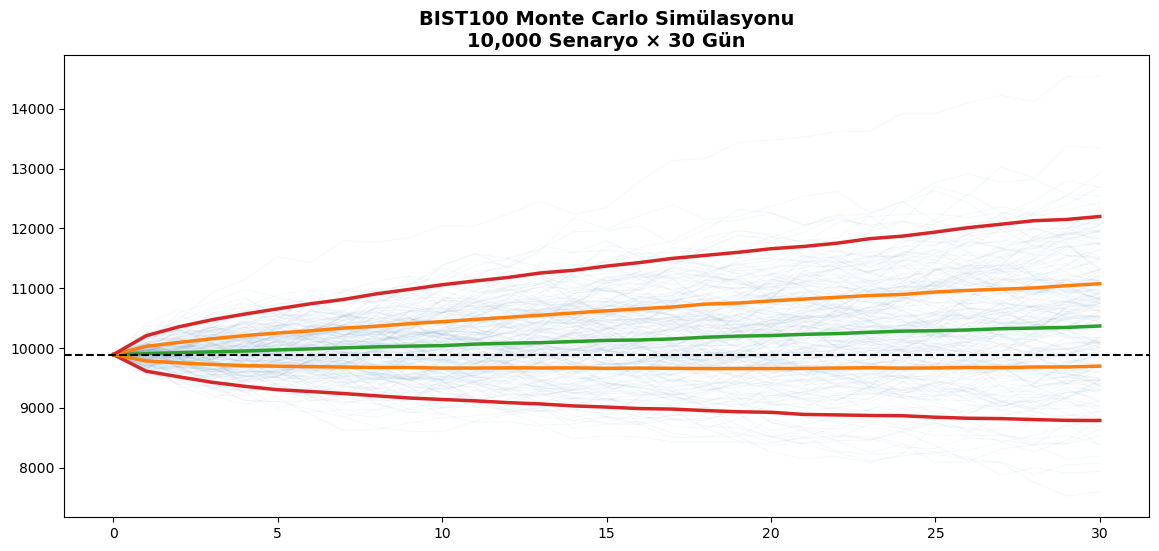

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

# 200 rastgele yol çiz (10.000 çizmek çok yavaş olur)
for i in range(200):
    ax.plot(fiyat_yollari[:, i], 
            color='steelblue', alpha=0.05, linewidth=0.8)

# Önemli yüzdelikleri kalın çiz
yuzdelikler = [5, 25, 50, 75, 95]
renkler     = ['#d62728', '#ff7f0e', '#2ca02c', '#ff7f0e', '#d62728']
etiketler   = ['%5 (kötü)', '%25', '%50 medyan', '%75', '%95 (iyi)']

for yuz, renk, etiket in zip(yuzdelikler, renkler, etiketler):
    yol = np.percentile(fiyat_yollari, yuz, axis=1)
    ax.plot(yol, color=renk, linewidth=2.5, label=etiket)

# Başlangıç çizgisi
ax.axhline(y=S0, color='black', linestyle='--', 
           linewidth=1.5, label=f'Başlangıç: {S0:,.0f}')

ax.set_title(f'BIST100 Monte Carlo Simülasyonu\n'
             f'{N_SENARYO:,} Senaryo × {N_GUN} Gün', 
             fontsize=14, fontweight='bold')
ax.set_xlabel